# 1. Titel och Frågeställning

## Kundsegmentering med PCA och UMAP

## Frågeställning
Hur kan olika datareduktionstekniker som PCA och UMAP användas för att identifiera mönster i kunders köpbeteende?


# 2. Datasetet

Datasetet Customer Personality Analysis är från Kaggle och innehåller information om kunders köpbeteende och demografi.

In [22]:
# imports
import pandas as pd
import umap.umap_ as umap
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from ipywidgets import interact, IntSlider, FloatSlider

# Ladda datasetet
df = pd.read_csv("/Users/victoria/Documents/aikurs/03_datareduktion/marketing_campaign.csv", sep="\t")

# Dataöversikt
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

# 3. Datarensning och skalning
Datasetet är relativt rent, men vi hanterar saknade värden i variabeln "Income" och väljer ut numeriska variabler relevanta för analysen.

In [23]:
# ta bort rader med saknade värden
df = df.dropna(subset=["Income"])

# kontrollera
print("\n Saknade värden (cleaned):")
print(df.isna().sum())

# väljer ut numeriska variabler

features = [
    "Income",
    "Recency",
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds",
    "NumWebPurchases", "NumCatalogPurchases",
    "NumStorePurchases", "NumWebVisitsMonth"
]

X = df[features]

# Skala numeriska variabler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


 Saknade värden (cleaned):
ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64


# 4. Exploratory Data Analysis (EDA) och Förberedelse

Vi undersöker samband mellan variabler.

Flera konsumtionsvariabler är starkt korrelerade, vilket tyder på att vissa kunder spenderar mer generellt.

<class 'pandas.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2216 non-null   int64  
 1   Year_Birth           2216 non-null   int64  
 2   Education            2216 non-null   str    
 3   Marital_Status       2216 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2216 non-null   int64  
 6   Teenhome             2216 non-null   int64  
 7   Dt_Customer          2216 non-null   str    
 8   Recency              2216 non-null   int64  
 9   MntWines             2216 non-null   int64  
 10  MntFruits            2216 non-null   int64  
 11  MntMeatProducts      2216 non-null   int64  
 12  MntFishProducts      2216 non-null   int64  
 13  MntSweetProducts     2216 non-null   int64  
 14  MntGoldProds         2216 non-null   int64  
 15  NumDealsPurchases    2216 non-null   int64  
 16  NumW

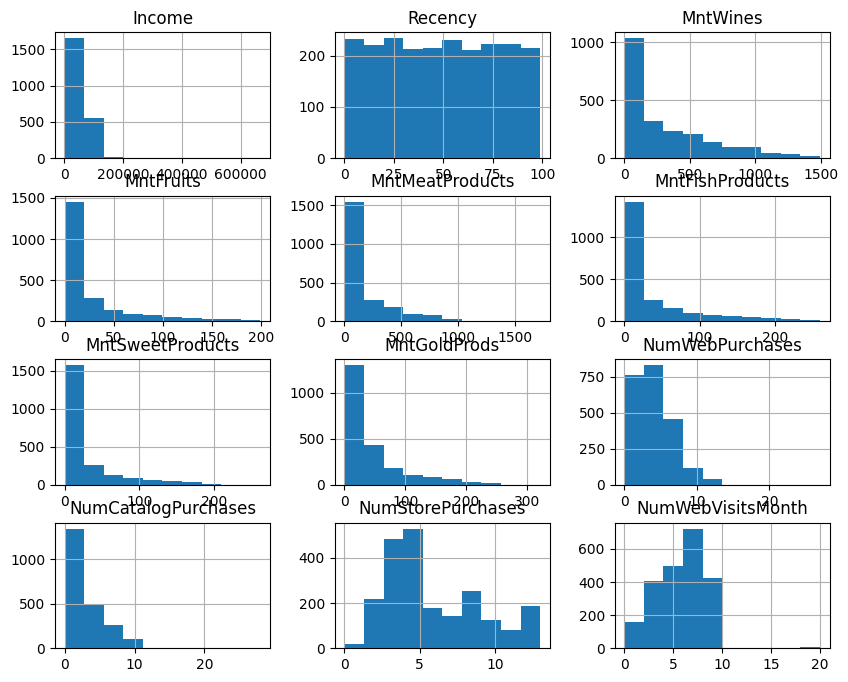

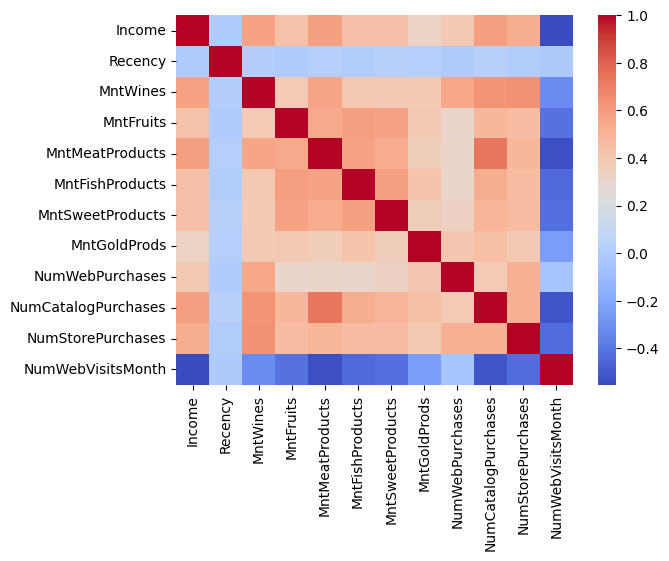

Marital Status: <StringArray>
['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone', 'Absurd',
 'YOLO']
Length: 8, dtype: str


In [24]:
df.shape
df.info()

df[features].hist(figsize=(10,8))
plt.show()

sns.heatmap(pd.DataFrame(X_scaled, columns=features).corr(), cmap="coolwarm")
plt.show()

print("Marital Status:", df["Marital_Status"].unique())
df["MaritalGroup"] = df["Marital_Status"].replace({
    "Married": "Partnered",
    "Together": "Partnered",
    
    "Single": "Single",
    "Divorced": "Single",
    "Widow": "Single",
    "Alone": "Single",
    
    "YOLO": "Other",
    "Absurd": "Other"
})

# 4. PCA

PCA används för att identifiera de viktigaste riktningarna i datan.

Den första komponenten representerar den totala konsumtionen, medan den andra visar skillnader i köpveteende

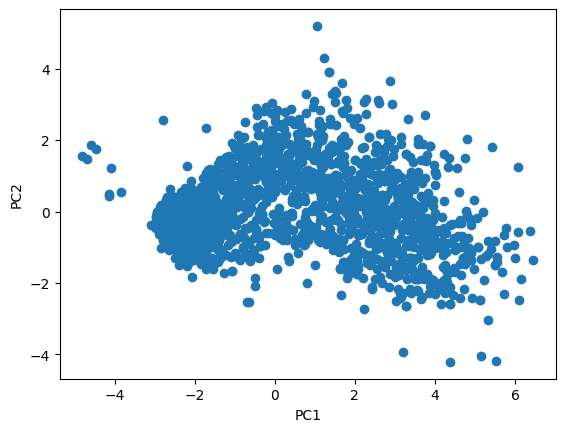

In [25]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# 5. UMAP
UMAP anväands för att identifiera kluster och lokala strukturer i datan. 

Till skillnad från PCA kan UMAP visa tydligare grupper av kunder.

In [26]:
fig = px.scatter(
    df,
    x="UMAP1",
    y="UMAP2",
    color="MaritalGroup",
    hover_data=["Income", "MntWines"],
    title="UMAP colored by Marital Group"
)

fig.show()

ValueError: Value of 'x' is not the name of a column in 'data_frame'. Expected one of ['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'MaritalGroup'] but received: UMAP1

# 6. Interaktiv visualisering
Vi använder en interaktiv graf för att utforska kunddata mer i detalj

In [ ]:
df["UMAP1"] = X_umap[:,0]
df["UMAP2"] = X_umap[:,1]

fig = px.scatter(
    df,
    x="UMAP1",
    y="UMAP2",
    color="Education",
    hover_data=["Income", "MntWines"]
)

fig.show()